## Setup

Create the environment from `env.yaml`, or install the pinned dependencies directly:

```
pip install -r reqs.txt
```

`reqs.txt` pins the versions the letter's results were produced with. The
PyTorch pin is CUDA-agnostic &mdash; install the build that matches your machine
from [pytorch.org](https://pytorch.org/get-started/locally/) if you need a
specific CUDA or ROCm version.

The capacity sweep uses `tqdm` for progress bars if it is installed, and falls
back to plain iteration if it is not.

Sections 8 and 10 read the WiSig subsets from `SingleDay.pkl`, `ManyTx.pkl` and
`ManySig.pkl` in the working directory; see `download_data.py`. Everything else
in this notebook runs on synthetic data generated on the fly.


# Measuring Disentanglement of RF-Fingerprint Feature Extractors

This notebook quantifies **how disentangled** the latent space of different
self-supervised feature extractors is, using the
[**DCI**](https://openreview.net/forum?id=By-7dz-AZ) framework
(*Disentanglement* and *Completeness*).

We use a **synthetic RF-fingerprinting dataset** where the ground-truth
device factors are *known by construction*. Each device is characterised by two
hardware impairments &mdash; a **carrier-frequency offset** (`cfo`) and an
**amplitude** deviation (`ampl`). Because we control the generative factors, we
can train an autoencoder in a purely self-supervised way and then measure
whether each latent dimension recovers a *single* physical factor.

**Pipeline**

1. Generate a synthetic 16-QAM dataset with per-device impairments.
2. Train an autoencoder feature extractor (reconstruction objective only).
3. Read out the bottleneck latents and compare them to the ground-truth factors via:
   * **DCI Disentanglement** &mdash; each latent encodes at most one factor.
   * **DCI Completeness** &mdash; each factor is captured by at most one latent.
   * **Spearman correlation** &mdash; a coarse global monotonicity check.

The headline comparison is between the **monotonic, polar KAN autoencoder
(MKAN)** introduced in this repository and a standard convolutional
autoencoder baseline.


## 1. Synthetic RF-fingerprinting dataset

Every sample is a single 256-sample burst built from a fixed 16-QAM symbol
sequence. Device-specific, *physically motivated* impairments are then applied:

* **Carrier-frequency offset** (`cfo`) &mdash; a slow phase rotation across the burst.
* **Amplitude scaling** (`ampl`).
* **I/Q gain / phase imbalance** (nuisance factors, not scored).

Finally an AWGN channel is applied at a random SNR. Items can be returned in
**polar form** &mdash; stacked `[magnitude, phase]` &mdash; which is the natural
input for the polar KAN encoder.

`full_range=True` uses all four quadrants (real levels `[-3, -1, 1, 3]`), which
is the setting the letter reports. `full_range=False` restricts the
constellation to the left half-plane, the confined proof-of-concept control.

The dataset and loaders live in `src/datasets.py`; the training split uses one
burst per device so that every sample carries a distinct factor vector, which
maximises the factor variation the DCI estimator needs.


In [ ]:
from src.datasets import get_synthetic_loaders
from src import experiments as exp
from src import figures as figs

FULL_RANGE = True        # False -> confined left half-plane control
CFO_COMPENSATE = False   # True  -> blind per-burst CFO removal
N_RUNS, N_EPOCHS = 10, 120

trainloader, valloader = get_synthetic_loaders(
    iq_imb=False, polar=False,
    full_range=FULL_RANGE, cfo_compensate=CFO_COMPENSATE,
)
ds_train, ds_test = trainloader.dataset, valloader.dataset

print(f"train: {len(ds_train)} bursts | eval: {len(ds_test)} bursts | "
      f"input shape {tuple(ds_train[0][0].shape)} | factors {ds_train.feature_names}")
print(f"device: {exp.DEVICE}")

## 2. Visualising a few bursts

Each burst is plotted in its polar `(magnitude, phase)` representation &mdash; the
exact input the feature extractors receive.


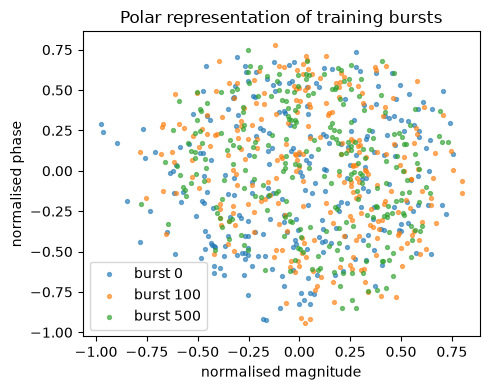

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
for idx in (0, 100, 500):
    mag, phase = ds_train[idx][0]
    ax.scatter(mag, phase, s=8, alpha=0.6, label=f"burst {idx}")
ax.set_xlabel("normalised magnitude")
ax.set_ylabel("normalised phase")
ax.set_title("Polar representation of training bursts")
ax.legend()
plt.tight_layout()
plt.show()

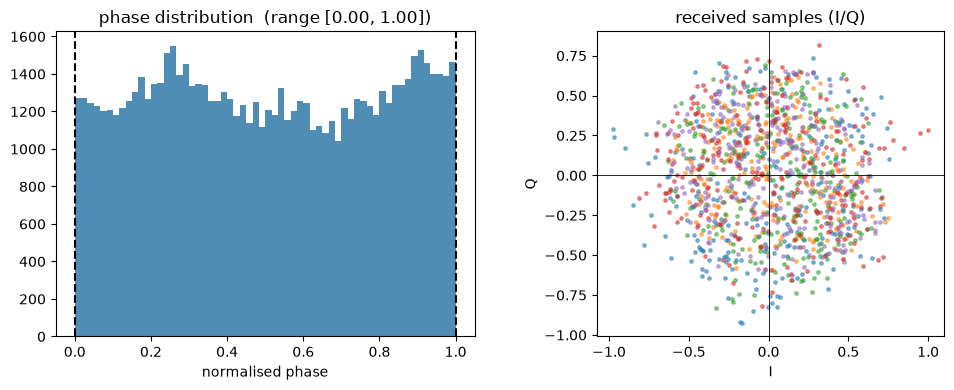

In [5]:
# --- Verify the synthetic phase range ---
import numpy as np, matplotlib.pyplot as plt
ds_train = get_synthetic_loaders(iq_imb=False, polar=True, full_range=True)[0].dataset
phs, iq_pts = [], []
for k in range(min(300, len(ds_train))):
    mag, ph = ds_train[k][0].numpy()
    phs.append(ph)
    if k < 5:
        r = mag * 1.5
        iq_pts.append((r*np.cos(ph*2*np.pi), r*np.sin(ph*2*np.pi)))
phs = np.concatenate(phs)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(phs, bins=60, color="#2471a3", alpha=.8)
ax[0].axvline(0, ls="--", c="k"); ax[0].axvline(1, ls="--", c="k")
ax[0].set_title(f"phase distribution  (range [{phs.min():.2f}, {phs.max():.2f}])")
ax[0].set_xlabel("normalised phase")
for I, Q in iq_pts:
    ax[1].scatter(I, Q, s=6, alpha=.5)
ax[1].axhline(0, c="k", lw=.6); ax[1].axvline(0, c="k", lw=.6)
ax[1].set_title("received samples (I/Q)"); ax[1].set_xlabel("I"); ax[1].set_ylabel("Q"); ax[1].set_aspect("equal")
plt.tight_layout(); plt.show()

## 3. The DCI disentanglement metric

We fit a gradient-boosted regressor from the learned latents to each
ground-truth factor and read off the **feature-importance matrix**
$R \in \mathbb{R}^{(\text{latents} \times \text{factors})}$, where $R_{ij}$ is the
importance of latent $i$ for predicting factor $j$.

* **Disentanglement** &mdash; for each latent, how *concentrated* its importance is
  across factors (1 = the latent predicts a single factor).
* **Completeness** &mdash; for each factor, how *concentrated* its importance is
  across latents (1 = the factor is predicted by a single latent).

Both are computed as $1 - \tfrac{H(p)}{H_{\max}}$, the normalised entropy of the
relevant (row / column) importance distribution.


## 4. Architectures under test

* **Polar MKAN** &mdash; the proposed encoder: polar input **and** block-partitioned
  monotonic connectivity, so `F_R` sees only magnitudes and `F_phi1`, `F_phi2`
  only phases.
* **MKAN** &mdash; monotonic KAN autoencoder on raw I/Q
  (`src/architectures/features_extractors/mkan.py`), i.e. monotonicity without
  the polar representation.
* **KAN** &mdash; the same autoencoder without the monotonic constraint.
* **CNN AE** &mdash; a standard 1-D convolutional autoencoder baseline
  (`src/architectures/features_extractors/cnn.py`).
* **Polar KAN** / **Polar CNN** &mdash; polar-input controls with unpartitioned
  encoders, which isolate the effect of the polar transform alone.

All models share a 3-dimensional bottleneck (`hidden_size = 3`) for the two
ground-truth factors and are trained with a pure reconstruction objective. The
registry is `experiments.AE_CONFIGS`.

## 5. Training and evaluation protocol

For each architecture, `experiments.evaluate_architecture` repeats the following
`N_RUNS` times and aggregates:

1. Train the autoencoder on the 1000-device training split for `N_EPOCHS` epochs.
2. Extract the bottleneck latents on the **independent 100-device evaluation split**.
3. Score disentanglement, completeness, Spearman correlation and the
   per-element reconstruction MSE on that same held-out split.

> The letter reports `N_RUNS = 10`, `N_EPOCHS = 120`. On CPU this is slow &mdash;
> lower them for a quick smoke test.

## 6. Results summary (letter Table I)

Mean &plusmn; 95% confidence interval over the runs. Higher disentanglement,
completeness and Spearman are better; lower reconstruction MSE is better.


In [22]:
all_results, summary = exp.run_dci_benchmark(
    iq_imb=True, lr=0.01,
    n_runs=N_RUNS, n_epochs=N_EPOCHS,
    full_range=FULL_RANGE, cfo_compensate=CFO_COMPENSATE,
)
summary

,disentanglement,completeness,spearman,recon_mse
architecture,,,,
MKAN,0.074 +/- 0.031,0.095 +/- 0.029,0.142 +/- 0.068,0.830 +/- 0.271
PolarMKAN,0.572 +/- 0.060,0.470 +/- 0.040,0.482 +/- 0.071,0.091 +/- 0.009
KAN,0.100 +/- 0.047,0.098 +/- 0.040,0.126 +/- 0.042,0.238 +/- 0.029
CNN AE,0.061 +/- 0.042,0.067 +/- 0.034,0.140 +/- 0.057,0.076 +/- 0.001
Polar KAN,0.129 +/- 0.048,0.131 +/- 0.049,0.590 +/- 0.102,0.080 +/- 0.005
Polar CNN,0.050 +/- 0.024,0.053 +/- 0.018,0.064 +/- 0.026,0.031 +/- 0.002


In [ ]:
exp.save_results(summary=summary, all_results=all_results)

## 7. Synthetic UED classification (letter Table II, Synthetic)

Clustering-based unknown-emitter detection on the synthetic benchmark: 200
devices with 20 bursts each, a fixed 25% of devices held out as unknown, run
uncompensated and with blind CFO compensation.


In [14]:
synth_ued_summary, synth_ued_perseed = exp.run_synthetic_ued(
    seeds=(0, 1, 2), n_epochs=120,
)
synth_ued_summary

=== synthetic UED | CNN | comp=False | seed=0 ===
=== synthetic UED | CNN | comp=False | seed=1 ===
=== synthetic UED | CNN | comp=False | seed=2 ===
  -> CNN comp=False: AUC 61.2 +/- 2.9
=== synthetic UED | CNN | comp=True | seed=0 ===
=== synthetic UED | CNN | comp=True | seed=1 ===
=== synthetic UED | CNN | comp=True | seed=2 ===
  -> CNN comp=True: AUC 51.7 +/- 0.6
=== synthetic UED | KAN | comp=False | seed=0 ===
=== synthetic UED | KAN | comp=False | seed=1 ===
=== synthetic UED | KAN | comp=False | seed=2 ===
  -> KAN comp=False: AUC 72.3 +/- 1.8
=== synthetic UED | KAN | comp=True | seed=0 ===
=== synthetic UED | KAN | comp=True | seed=1 ===
=== synthetic UED | KAN | comp=True | seed=2 ===
  -> KAN comp=True: AUC 51.1 +/- 1.3
=== synthetic UED | MKAN | comp=False | seed=0 ===
=== synthetic UED | MKAN | comp=False | seed=1 ===
=== synthetic UED | MKAN | comp=False | seed=2 ===
  -> MKAN comp=False: AUC 72.9 +/- 3.1
=== synthetic UED | MKAN | comp=True | seed=0 ===
=== synthetic 

roc_auc_mean  roc_auc_std   f1_mean    f1_std  \
architecture cfo_compensate                                                  
CNN          False               0.611934     0.028547  0.633718  0.031468   
             True                0.516725     0.006407  0.493695  0.020663   
KAN          False               0.722843     0.017551  0.814116  0.007916   
             True                0.511232     0.013043  0.494866  0.016328   
MKAN         False               0.728872     0.030660  0.794722  0.033640   
             True                0.490111     0.002355  0.497535  0.018386   
Polar MKAN   False               0.684010     0.052861  0.748764  0.044296   
             True                0.516280     0.007137  0.509705  0.010828   
Polar KAN    False               0.573649     0.040130  0.629191  0.041421   
             True                0.512964     0.009899  0.495902  0.023647   
Polar CNN    False               0.527482     0.015803  0.569991  0.015354   
             True                0.494857     0.011917  0.514067  0.023147   

                             precision_mean  precision_std  recall_mean  \
architecture cfo_compensate                                               
CNN          False                 0.724088       0.022438     0.563667   
             True                  0.636968       0.005959     0.403333   
KAN          False                 0.766565       0.006611     0.868000   
             True                  0.641057       0.010225     0.403333   
MKAN         False                 0.775544       0.017484     0.815333   
             True                  0.616972       0.010365     0.417000   
Polar MKAN   False                 0.758614       0.027931     0.739667   
             True                  0.638456       0.003598     0.424333   
Polar KAN    False                 0.690498       0.035694     0.578000   
             True                  0.632327       0.014589     0.408333   
Polar CNN    False                 0.644262       0.008510     0.511333   
             True                  0.620855       0.005894     0.439333   

                             recall_std  accuracy_mean  accuracy_std  
architecture cfo_compensate                                           
CNN          False             0.037233       0.593333      0.029090  
             True              0.025106       0.483542      0.010390  
KAN          False             0.012000       0.752292      0.009928  
             True              0.022008       0.485833      0.007864  
MKAN         False             0.051868       0.737500      0.038140  
             True              0.021517       0.473958      0.011930  
Polar MKAN   False             0.060451       0.690833      0.048559  
             True              0.015308       0.490000      0.004098  
Polar KAN    False             0.044911       0.574792      0.042657  
             True              0.029023       0.481875      0.014087  
Polar CNN    False             0.022301       0.518125      0.010327  
             True              0.033247       0.481875      0.009333

## 8. WiSig UED evaluation (letter Table II, SingleDay and ManyTx)

Real-data UED over device-level open-set folds. Switch `subset` to `"ManyTx"`
for the 150-emitter set; `"ManySig"` is a small subset useful for smoke tests.
Requires the corresponding `.pkl` in the working directory.


In [9]:
wisig_summary, wisig_perfold = exp.run_wisig_ued(
    subset="SingleDay", n_epochs=120,
)
wisig_summary

=== SingleDay | CNN | cfo_compensate=False ===
      fold 0 | epoch 1/120 | loss=0.4877
      fold 0 | epoch 11/120 | loss=0.3270
      fold 0 | epoch 21/120 | loss=0.3245
      fold 0 | epoch 31/120 | loss=0.3235
      fold 0 | epoch 41/120 | loss=0.3233
      fold 0 | epoch 51/120 | loss=0.3226
      fold 0 | epoch 61/120 | loss=0.3224
      fold 0 | epoch 71/120 | loss=0.3220
      fold 0 | epoch 81/120 | loss=0.3216
      fold 0 | epoch 91/120 | loss=0.3216
      fold 0 | epoch 101/120 | loss=0.3217
      fold 0 | epoch 111/120 | loss=0.3218
      fold 0 | epoch 120/120 | loss=0.3218
    fold 0: roc_auc=0.675  f1=0.394  precision=0.548  recall=0.307  accuracy=0.865
      fold 1 | epoch 1/120 | loss=0.5104
      fold 1 | epoch 11/120 | loss=0.3296
      fold 1 | epoch 21/120 | loss=0.3254
      fold 1 | epoch 31/120 | loss=0.3243
      fold 1 | epoch 41/120 | loss=0.3238
      fold 1 | epoch 51/120 | loss=0.3239
      fold 1 | epoch 61/120 | loss=0.3235
      fold 1 | epoch 71/120 |

roc_auc_mean   f1_mean  precision_mean  \
architecture cfo_compensate                                           
CNN          False               0.695870  0.352420        0.501143   
             True                0.695594  0.307078        0.464622   
KAN          False               0.905441  0.692164        0.717379   
             True                0.728965  0.423855        0.559662   
MKAN         False               0.824602  0.534653        0.623933   
             True                0.653330  0.290359        0.443653   
Polar MKAN   False               0.715806  0.375356        0.515152   
             True                0.673054  0.295461        0.453423   
Polar KAN    False               0.805367  0.526061        0.627729   
             True                0.699206  0.343616        0.494836   
Polar CNN    False               0.627544  0.225060        0.373123   
             True                0.590925  0.160809        0.298294   

                             recall_mean  accuracy_mean  roc_auc_std  \
architecture cfo_compensate                                            
CNN          False              0.274911       0.860128     0.053907   
             True               0.231116       0.853858     0.042335   
KAN          False              0.674152       0.916607     0.057254   
             True               0.344241       0.869388     0.058778   
MKAN         False              0.479598       0.888878     0.067147   
             True               0.217857       0.851575     0.047694   
Polar MKAN   False              0.299687       0.863055     0.080257   
             True               0.219911       0.851996     0.044034   
Polar KAN    False              0.459509       0.886161     0.062078   
             True               0.265268       0.858304     0.048202   
Polar CNN    False              0.162723       0.843897     0.043680   
             True               0.110223       0.836531     0.021822   

                               f1_std  precision_std  recall_std  accuracy_std  
architecture cfo_compensate                                                     
CNN          False           0.109237       0.098894    0.100934      0.014432  
             True            0.082175       0.076241    0.074146      0.010488  
KAN          False           0.090245       0.045616    0.123191      0.017733  
             True            0.094828       0.072265    0.095996      0.013635  
MKAN         False           0.162992       0.108173    0.187838      0.026855  
             True            0.092111       0.089379    0.081645      0.011651  
Polar MKAN   False           0.122949       0.103987    0.117856      0.016726  
             True            0.067364       0.074878    0.055957      0.007994  
Polar KAN    False           0.119269       0.075136    0.138849      0.020021  
             True            0.089760       0.082660    0.081935      0.011607  
Polar CNN    False           0.086005       0.092537    0.072682      0.010338  
             True            0.036629       0.053244    0.027093      0.003896

## 9. Model size and compute

Parameter counts and forward-pass timing. "Active" counts scalars with non-zero
gradient support, so Polar MKAN's structurally pruned edges are excluded.


In [33]:
exp.model_size_table(latex=True)

              Params  Active  Active %  Fwd (ms)
Architecture                                    
CNN            71397   33901      47.5     1.713
KAN            43008   34816      81.0     0.588
MKAN           49669   35328      71.1     1.246
Polar CNN      71397   55767      78.1     1.301
Polar KAN      43008   35328      82.1     0.582
Polar MKAN     49669   25344      51.0     1.082

Forward-pass FLOPs (torch native; elementwise spline ops may be under-counted):
  CNN         5.103 MFLOPs
  KAN         0.080 MFLOPs
  MKAN        0.080 MFLOPs
  Polar CNN   5.103 MFLOPs
  Polar KAN   0.080 MFLOPs
  Polar MKAN  0.080 MFLOPs

% --- LaTeX table body ---
\begin{tabular}{lccc}
\toprule
FE & Params & Active & Active\% \\ \midrule
CNN & 71,397 & 33,901 & 48\% \\
KAN & 43,008 & 34,816 & 81\% \\
MKAN & 49,669 & 35,328 & 71\% \\
Polar CNN & 71,397 & 55,767 & 78\% \\
Polar KAN & 43,008 & 35,328 & 82\% \\
Polar MKAN & 49,669 & 25,344 & 51\% \\
\bottomrule
\end{tabular}


## 10. Capacity sweep

Varies the KAN `grid_size` for Polar MKAN against KAN and reports DCI alongside
WiSig UED, to check that the disentanglement gap is not a capacity artefact.


In [13]:
sweep = exp.run_capacity_sweep(
    grid_sizes=(16, 32), archs=("Polar MKAN", "KAN"),
    subset="ManySig", wisig_epochs=120, dci_runs=1, dci_epochs=120,
)
sweep

ModuleNotFoundError: No module named 'wandb'

## 11. Perturbation analysis

Multi-seed phase and amplitude perturbation sweep on the evaluation split,
followed by the guarantee check that separates monotonicity (an implementation
property) from circularity (the branch-cut effect).

Checkpoints are cached under `ckpt/`, so a second run reuses them instead of
retraining.


In [32]:
perturbation = exp.run_perturbation_analysis(n_seeds=10, n_epochs=120)

PolarMKAN seed 0: sign_phi1=0.575  sign_phi2=0.596  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 1: sign_phi1=0.645  sign_phi2=0.544  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 2: sign_phi1=0.673  sign_phi2=0.621  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 3: sign_phi1=0.607  sign_phi2=0.652  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 4: sign_phi1=0.654  sign_phi2=0.540  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 5: sign_phi1=0.491  sign_phi2=0.588  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 6: sign_phi1=0.590  sign_phi2=0.568  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 7: sign_phi1=0.618  sign_phi2=0.778  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 8: sign_phi1=0.498  sign_phi2=0.576  sign_R=1.000  leak_phase->R=0.000  leak_amp->phi=0.000
PolarMKAN seed 9: sign_phi1=0.670  si

In [33]:
guarantee = exp.run_guarantee_check(n_seeds=10)

Probe A  clamped shift, sign>=0 rate : 1.0000  (expected 1.0000)
Probe B  wrap-free bursts, mod shift : 1.0000  over 2730 wrap-free burst-alpha pairs (expected 1.0000)


## 12. Phase branch-cut validation

Applies the physical rotation `phi' = (phi + alpha) mod 2pi` and bins the sign
consistency of the phase features by the fraction of samples that cross the
branch cut. At 0% wrapping the consistency should be ~1.0; it degrades
gradually as wrapping becomes widespread.


=== Polar MKAN seed 0 ===
  F_phi1: [1.    0.698 0.57  0.479 0.428]
  F_phi2: [1.    0.703 0.67  0.559 0.125]
=== Polar MKAN seed 1 ===
  F_phi1: [1.    0.639 0.482 0.347 0.086]
  F_phi2: [1.    0.667 0.608 0.505 0.155]
=== Polar MKAN seed 2 ===
  F_phi1: [1.    0.742 0.654 0.645 0.306]
  F_phi2: [1.    0.707 0.664 0.597 0.201]
=== Polar MKAN seed 3 ===
  F_phi1: [1.    0.71  0.637 0.577 0.161]
  F_phi2: [1.    0.698 0.624 0.579 0.447]
=== Polar MKAN seed 4 ===
  F_phi1: [1.    0.733 0.698 0.613 0.352]
  F_phi2: [1.    0.686 0.575 0.473 0.089]
=== Polar MKAN seed 5 ===
  F_phi1: [1.    0.679 0.532 0.424 0.168]
  F_phi2: [1.    0.66  0.626 0.525 0.237]
=== Polar MKAN seed 6 ===
  F_phi1: [1.    0.726 0.667 0.57  0.164]
  F_phi2: [1.    0.679 0.589 0.522 0.263]
=== Polar MKAN seed 7 ===
  F_phi1: [1.    0.745 0.695 0.584 0.178]
  F_phi2: [1.    0.77  0.735 0.759 0.651]
=== Polar MKAN seed 8 ===
  F_phi1: [1.    0.646 0.551 0.445 0.125]
  F_phi2: [1.    0.698 0.603 0.527 0.194]
=== Polar 

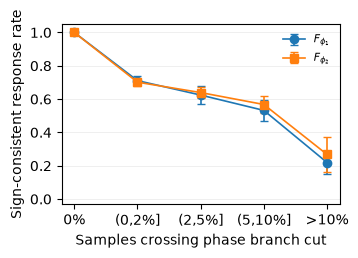

In [24]:
wrap = exp.run_branch_cut_validation(n_seeds=10, n_epochs=120)

## 13. Figures for the letter

`tradeoff_scatter_heldout.pdf` (Fig. 5) and `phase_wrap_consistency.pdf` (Fig. 4).
The scatter is drawn from saved CSVs, so it can be regenerated without rerunning
the experiments &mdash; point the two paths at your own run to redraw it.


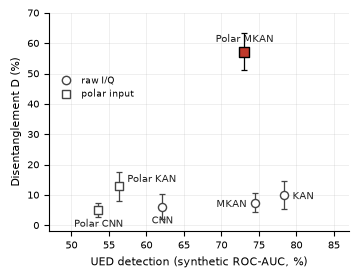

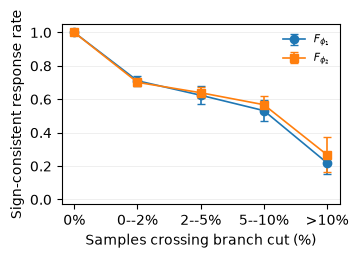

In [28]:
figs.plot_tradeoff_scatter(
    dci_csv="results/synthetic_dci_20260812_105624.csv",
    ued_csv="results/synthetic_ued_20260806_144410.csv",
)

In [ ]:
figs.plot_phase_wrap(wrap["means"], wrap["ci95"])